In [49]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Reshape, Flatten, Dropout, LeakyReLU,UpSampling2D, BatchNormalization
from keras.utils import plot_model
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam


In [26]:
from keras.datasets.cifar10 import load_data
from matplotlib import pyplot

# Load the images into memory
(xtrain, ytrain),(xtest, ytest) = load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


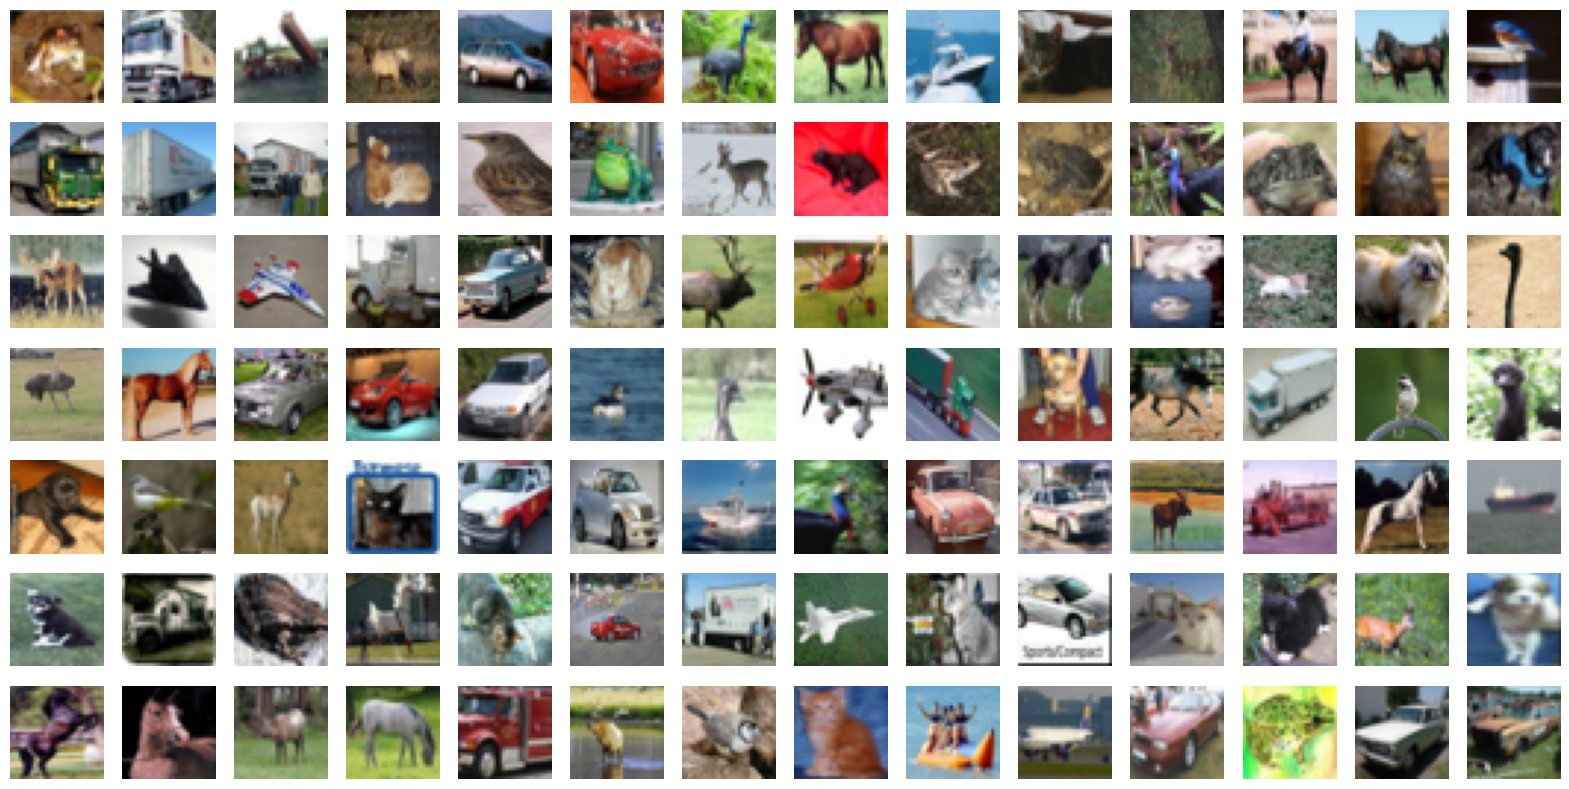

In [30]:
#plot image from the training dataset
plt.figure(figsize=(20, 10))
for i in range(98):
  plt.subplot(7, 14, i+1)
  plt.axis('off')
  plt.imshow(xtrain[i])
plt.show()

In [69]:
# Define Generator


def define_generator(latent_dim):
  model = Sequential()
  model.add(Dense(8*8*256, input_dim=latent_dim)) # Dense layer to upscale latent vector
  # Reshape to 8x8x256 feature map - provide the target shape as a tuple
  model.add(Reshape((8,8,256)))
  model.add(BatchNormalization()) # BatchNormalization is a class, needs to be instantiated
  model.add(LeakyReLU(0.2))

  model.add(UpSampling2D())   # Upsample to 16x16
  model.add(Conv2D(128, kernel_size=(3,3), padding='same')) # Conv layer with 128 filters
  model.add(BatchNormalization()) # BatchNormalization is a class, needs to be instantiated
  model.add(LeakyReLU(0.2))

  # Add another upsampling and convolutional layer to reach 32x32
  model.add(UpSampling2D())   # Upsample to 32x32
  model.add(Conv2D(64, kernel_size=(3,3), padding='same')) # Conv layer with 64 filters
  model.add(BatchNormalization())
  model.add(LeakyReLU(0.2))


  model.add(Conv2D(3, kernel_size=3, padding='same', activation='tanh'))
  return model



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 16384)          │     1,654,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_12 (Reshape)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_50 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_51 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_52 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,139 (7.73 MB)

 Trainable params: 2,026,243 (7.73 MB)

 Non-trainable params: 896 (3.50 KB)

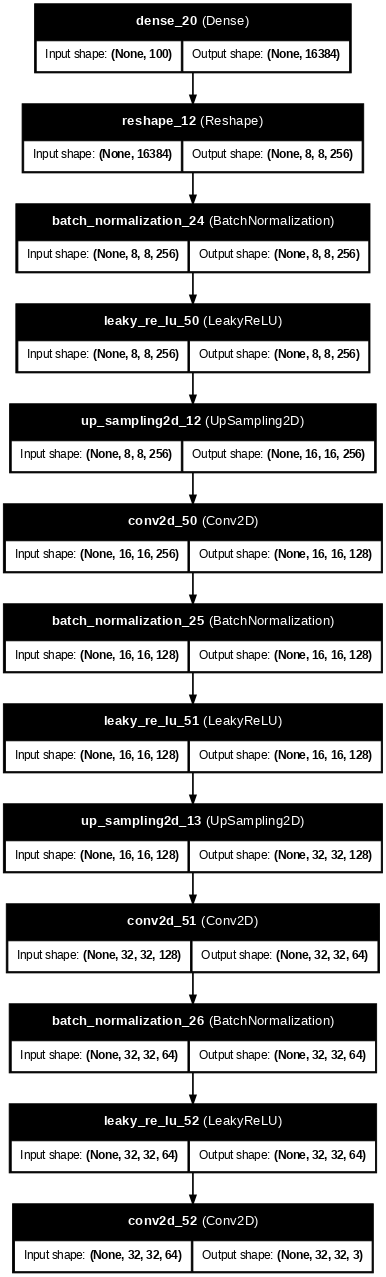

In [70]:
model = define_generator(100)

# sumarize the model
model.summary()
# Reduce the dpi for a smaller output file
plot_model(model, to_file='generator_plot.png', show_shapes=True, show_layer_names=True, dpi=60)

In [71]:
#define the standalone discriminator model
def define_discriminator(in_shape=(32,32,3)):
    model = Sequential()
    model.add(Conv2D(64, kernel_size=3, padding='same', input_shape=in_shape))  # Conv layer 64 filters
    model.add(LeakyReLU(0.2))                                                  # Activation

    model.add(Conv2D(128, kernel_size=3, strides=2, padding='same'))            # Downsample + conv
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(256, kernel_size=3, strides=2, padding='same'))            # Further downsample + conv
    model.add(LeakyReLU(0.2))

    model.add(Flatten())                                                       # Flatten feature maps
    model.add(Dropout(0.4))                                                    # Dropout to reduce overfitting
    model.add(Dense(1, activation='sigmoid'))                                 # Binary classifier output

    opt = Adam(learning_rate=0.0002, beta_1=0.5)                              # Adam optimizer with lr and beta1
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy']) # Compile with BCE loss
    return model





/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_53 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_53 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_54 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_55 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387,201 (1.48 MB)

 Trainable params: 387,201 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

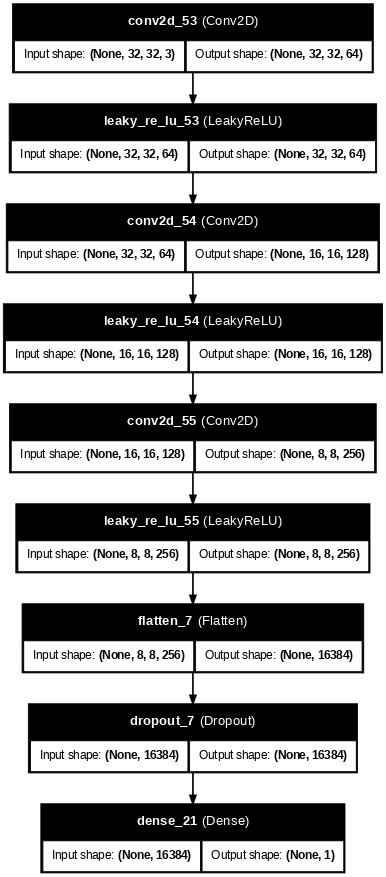

In [72]:
model = define_discriminator()

# sumarize the model
model.summary()
plot_model(model, to_file='discriminator_plot.png', show_shapes=True, show_layer_names=True,dpi=60)

In [73]:
# Define Gan model (Generator + Discriminator combined)

def define_gan(generator, discriminator):
  discriminator.trainable=False # Freeze discriminator weights for GAN training
  model = Sequential()
  model.add(generator)
  model.add(discriminator)

  # Fix typo in learning_rate
  opt = Adam(learning_rate=0.0002, beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
  return model


In [74]:
# Fake image plot function

def plot_fake_images(generator, latent_dim, n=8):
    noise = np.random.randn(n*n, latent_dim)                               # Random noise vector
    gen_imgs = generator.predict(noise)                                    # Generate fake images
    gen_imgs = 0.5 * gen_imgs + 0.5                                        # Rescale images to [0,1] for visualization

    fig, axs = plt.subplots(n, n, figsize=(8,8))                           # Prepare subplot grid
    cnt = 0
    for i in range(n):
        for j in range(n):
            axs[i,j].imshow(gen_imgs[cnt])                                 # Show image
            axs[i,j].axis('off')                                           # Remove axes
            cnt += 1
    plt.tight_layout()
    plt.show()


In [89]:
# Training function

def train(generator, discriminator, gan_model, dataset, latent_dim, epochs=1000,batch_size=64,save_interval=500):
  half_batch = batch_size // 2    # Half batch for real/fake

  for i in range(epochs):
    # Train Discriminator with real image
    idx = np.random.randint(0, dataset.shape[0], half_batch) # Random real images index
    real_imgs = dataset[idx]  # Real images batch
    y_real = np.ones((half_batch, 1))  # Labels for real images = 1


    # Train discriminator with fake images
    noise = np.random.randn(half_batch,latent_dim)  # Random noise
    fake_imgs = generator.predict(noise)  # Generate fake images
    y_fake = np.zeros((half_batch, 1))           # Labels for fake images = 0


    # Train discriminator on real and fake images
    d_loss_real = discriminator.train_on_batch(real_imgs, y_real) # Train discriminator on real
    d_loss_fake = discriminator.train_on_batch(fake_imgs, y_fake) # Train discriminator on fake
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.randn(batch_size, latent_dim)     # Noise input
    y_gan = np.ones((batch_size, 1))        # Labels are real to fool D
    g_loss = gan_model.train_on_batch(noise, y_gan) # Train generator

    # Print progress every 100 epochs
    if (i+1) % 100 == 0:
      # Access the loss value from the g_loss list using index [0]
      print(f"Epoch {i+1}/{epochs} | D loss: {d_loss[0]:.3f}, acc: {d_loss[1]*100:.2f}% | G loss: {g_loss[0]:.3f}")

   # Save/plot images every save_interval epochs
    if (i+1) % save_interval == 0:
        print(f"Saving generated images at epoch {i+1}")
        plot_fake_images(generator, latent_dim)

In [ ]:

# Main execution
latent_dim = 100                                  # Size of noise vector
generator = define_generator(latent_dim)          # Create generator
discriminator = define_discriminator()            # Create discriminator
gan_model = define_gan(generator, discriminator)  # Create combined GAN model

# Start training
train(generator, discriminator, gan_model, xtrain, latent_dim, epochs=1000, batch_size=64, save_interval=500)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [82]:
# 🧪 Evaluate the discriminator after GAN training
def evaluate_discriminator(discriminator, generator, dataset, latent_dim):

    #  1. Select 100 random real images from the dataset
    idx = np.random.randint(0, dataset.shape[0], 100)  # Random index
    real_imgs = dataset[idx]                           # Real images
    y_real = np.ones((100, 1))                         # Label them as real (1)

    # 2. Generate 100 fake images from noise using the generator
    noise = np.random.randn(100, latent_dim)           # Random noise vectors
    fake_imgs = generator.predict(noise)               # Fake images
    y_fake = np.zeros((100, 1))                        # Label them as fake (0)

    #  3. Evaluate discriminator on real images
    real_loss, real_acc = discriminator.evaluate(real_imgs, y_real, verbose=0)

    #  4. Evaluate discriminator on fake images
    fake_loss, fake_acc = discriminator.evaluate(fake_imgs, y_fake, verbose=0)

    #  5. Print out the accuracy on both real and fake images
    print(f"Discriminator Accuracy on Real Images: {real_acc * 100:.2f}%")
    print(f"Discriminator Accuracy on Fake Images: {fake_acc * 100:.2f}%")


In [88]:
evaluate_discriminator(discriminator, generator, xtrain, latent_dim)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step
Discriminator Accuracy on Real Images: 100.00%
Discriminator Accuracy on Fake Images: 0.00%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step


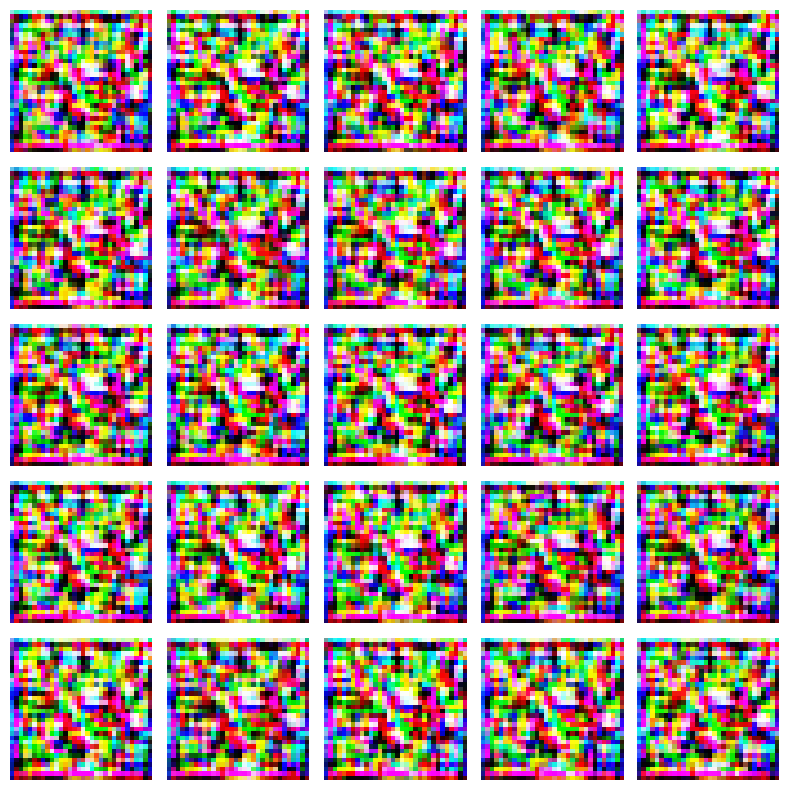

In [83]:
# Generate and plot fake images after training
plot_fake_images(generator, latent_dim, n=5)  # 5x5 grid of images


In [84]:
# Save the generator model
generator.save('cifar10_generator_model.h5')  # Save as HDF5 file
print("Generator model saved.")


Generator model saved.


In [85]:
from tensorflow.keras.models import load_model
generator = load_model('cifar10_generator_model.h5')


In [86]:
# Generate and save images from the trained generator
def generate_and_save_images(generator, latent_dim, filename='generated.png', n=5):
    noise = np.random.randn(n*n, latent_dim)
    gen_imgs = generator.predict(noise)
    gen_imgs = 0.5 * gen_imgs + 0.5  # Rescale to [0, 1]

    fig, axs = plt.subplots(n, n, figsize=(n, n))
    cnt = 0
    for i in range(n):
        for j in range(n):
            axs[i, j].imshow(gen_imgs[cnt])
            axs[i, j].axis('off')
            cnt += 1
    plt.tight_layout()
    plt.savefig(filename)  # Save the figure
    plt.show()
    print(f"Images saved to {filename}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


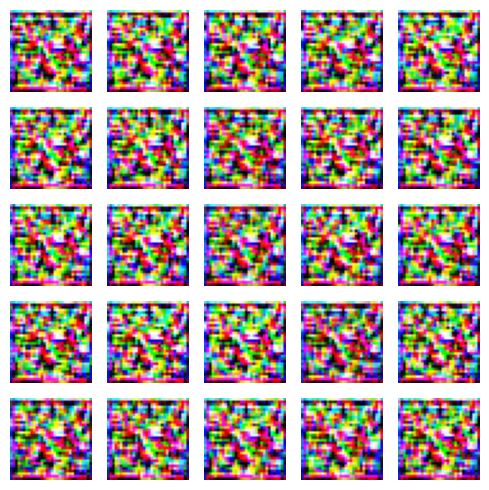

Images saved to final_generated.png


In [87]:
generate_and_save_images(generator, latent_dim, 'final_generated.png', n=5)
